# Time Series

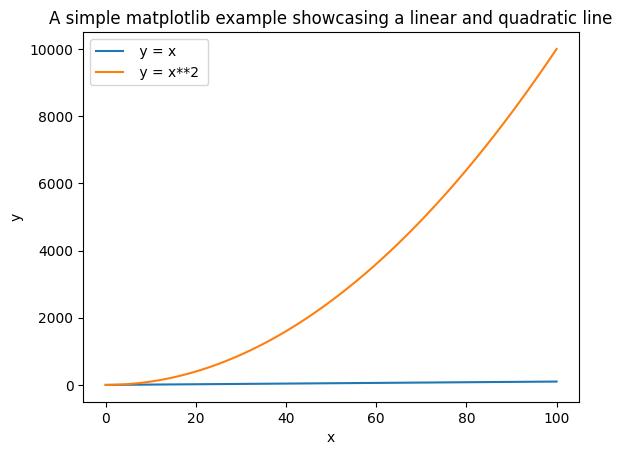

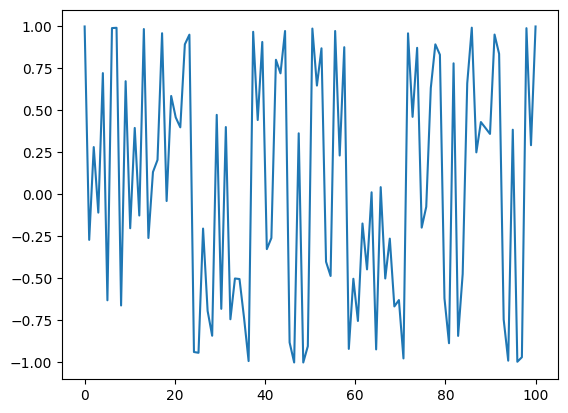

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.signal import chirp

x = np.linspace(0,100,100)

plt.plot(x,x,label=' y = x')
plt.plot(x,x**2,label=' y = x**2 ')
plt.title('A simple matplotlib example showcasing a linear and quadratic line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

chirp_signal = chirp(
                        x,
                        f0=1.5,
                        f1=3,
                        t1=4,
                        method='linear'
                    )

plt.plot(x,chirp_signal)
plt.show()

## Components of Time Series 

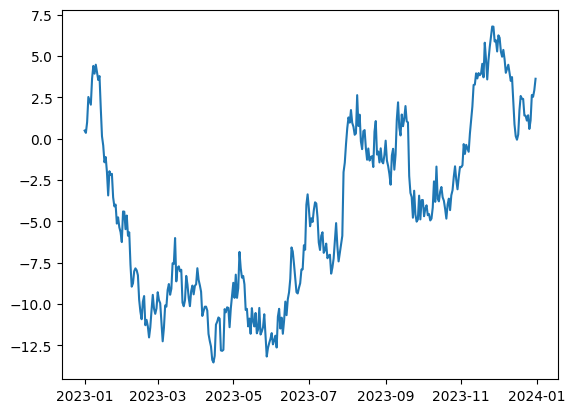

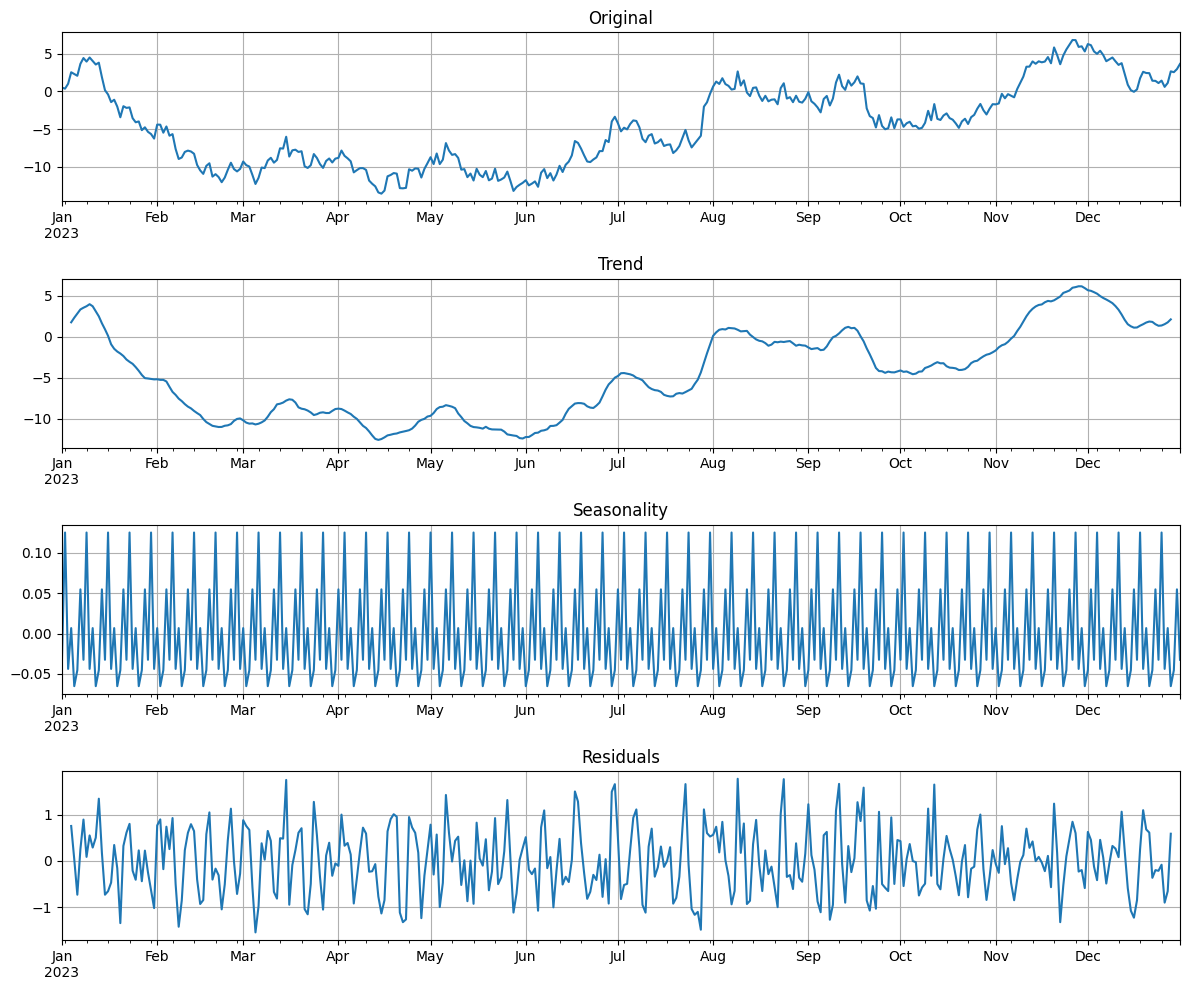

In [ ]:
import statsmodels.api as sm
import pandas as pd

data_values = pd.date_range(start='2023-01-01',end='2023-12-31',freq='D')
np.random.seed(42)

values = np.random.randn(len(data_values)).cumsum()
time_series = pd.DataFrame(
                            {
                                'value':values
                            },
                            index = data_values
)

plt.plot(time_series)
plt.show()

decomposed_graph = sm.tsa.seasonal_decompose(time_series['value'],model='additive',period=7)    

# decomposed_graph.plot()
# plt.show()

# --- Plot all 4 components ---
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

time_series["value"].plot(ax=axes[0], title="Original")
decomposed_graph.trend.plot(ax=axes[1], title="Trend")
decomposed_graph.seasonal.plot(ax=axes[2], title="Seasonality")
decomposed_graph.resid.plot(ax=axes[3], title="Residuals")

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()

# ARIMA 

Step 1: Predicted = 293.3, Actual = 339.7
Step 2: Predicted = 368.7, Actual = 440.4
Step 3: Predicted = 335.0, Actual = 315.9
Step 4: Predicted = 363.2, Actual = 439.3
Step 5: Predicted = 357.6, Actual = 401.3
Step 6: Predicted = 443.0, Actual = 437.4
Step 7: Predicted = 378.4, Actual = 575.5
Step 8: Predicted = 459.4, Actual = 407.6
Step 9: Predicted = 526.9, Actual = 682.0
Step 10: Predicted = 457.2, Actual = 475.3
Step 11: Predicted = 672.9, Actual = 581.3
Step 12: Predicted = 531.5, Actual = 646.9

RMSE: 92.66


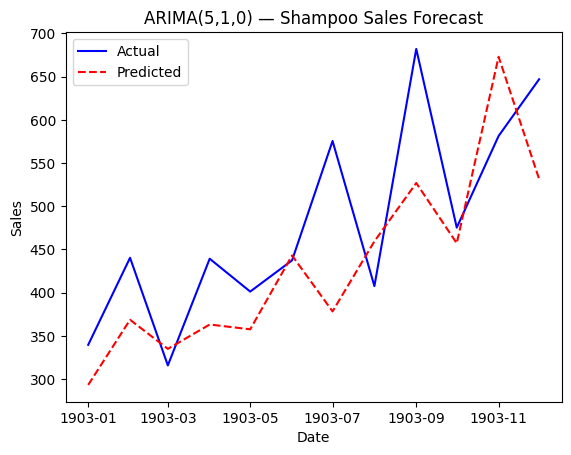

In [272]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error
from math import sqrt

# Load and ensure it's a Series
df = pd.read_csv('shampoo_sales.csv', header=0, index_col=0)
series = df.iloc[:, 0]

# Fix the index
series.index = pd.to_datetime("190" + series.index, format="%Y-%m").to_period("M")
values = series.values

index_to_split = int(len(values)*0.67)
training_set , testing_set = series[:index_to_split] , series[index_to_split : ]

history = list(training_set)
predictions = []

for test in range(len(testing_set)):
    model = ARIMA(history, order=(5,1,0))
    fit = model.fit()
    forecast = fit.forecast()[0]
    
    predictions.append(forecast)
    # Use .iloc to avoid KeyError
    actual_value = testing_set.iloc[test]
    history.append(actual_value)
    
    print(f'Step {test+1}: Predicted = {forecast:.1f}, Actual = {actual_value:.1f}')

rmse = sqrt(mean_squared_error(testing_set, predictions))
print(f"\nRMSE: {rmse:.2f}")

# Convert everything to Timestamps and Series first
actual_plot = testing_set.to_timestamp()
# Create a Series for predictions with the EXACT same index
pred_series = pd.Series(predictions, index=actual_plot.index)

# Plotting
plt.plot(actual_plot, label="Actual", color="blue")
plt.plot(pred_series, label="Predicted", color="red", linestyle="--")

plt.title("ARIMA(5,1,0) — Shampoo Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


RMSE: 44.71


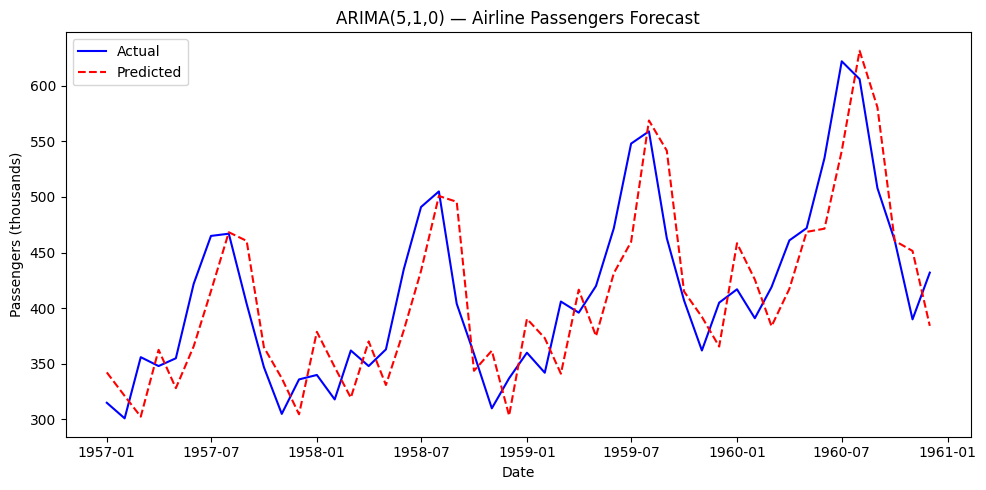

In [273]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

# ---- Load directly from statsmodels — no CSV needed ----
data = sm.datasets.get_rdataset("AirPassengers", "datasets").data
# Columns: time (1949.000, 1949.083...), value (passengers in thousands)

# Convert the decimal year column into a proper monthly DatetimeIndex
data.index = pd.date_range(start="1949-01", periods=len(data), freq="MS")
series = data["value"]


# ---- Train/test split ----
split = int(len(series) * 0.67)
train, test = series[:split], series[split:]

# ---- Rolling ARIMA forecast ----
history = list(train)
predictions = []

for actual in test:
    model = ARIMA(history, order=(5, 1, 0))
    forecast = model.fit().forecast()[0]
    predictions.append(forecast)
    history.append(actual)

# ---- Evaluate ----
rmse = sqrt(mean_squared_error(test, predictions))
print(f"RMSE: {rmse:.2f}")

# ---- Plot ----
plt.figure(figsize=(10, 5))
plt.plot(test.index, test.values, label="Actual", color="blue")
plt.plot(test.index, predictions, label="Predicted", color="red", linestyle="--")
plt.title("ARIMA(5,1,0) — Airline Passengers Forecast")
plt.xlabel("Date")
plt.ylabel("Passengers (thousands)")
plt.legend()
plt.tight_layout()
plt.show()

# Sentiment Analysis

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# --- Load data ---
# spam.csv columns: Category (spam/ham), Message (text)
df = pd.read_csv("spam.csv", encoding="latin1")
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df.columns=["Category", "Message"]

# Convert text labels to numbers: spam=1, ham=0
df["label"] = (df["Category"] == "spam").astype(int)
print(df.groupby("Category").size())  # See class distribution

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    df["Message"], df["label"],
    test_size=0.25,  # 25% for testing
    random_state=42  # reproducibility
)

# --- Convert text to numbers (Bag of Words) ---
vectorizer = CountVectorizer()

# fit_transform on training data: LEARNS the vocabulary AND converts text
X_train_counts = vectorizer.fit_transform(X_train)

# transform on test data: uses SAME vocabulary (never fit on test data!)
X_test_counts = vectorizer.transform(X_test)

# --- Train Naive Bayes ---
model = MultinomialNB()
# MultinomialNB: designed for word count features (non-negative integers)
model.fit(X_train_counts, y_train)

# --- Test with custom emails ---
def predict_email(text):
    vec = vectorizer.transform([text])
    prediction = model.predict(vec)[0]
    return "SPAM" if prediction == 1 else "HAM (not spam)"

print(predict_email("baseball tickets later tonight"))      # HAM
print(predict_email("reward money click here to win now")) # SPAM

# --- Overall accuracy ---
accuracy = model.score(X_test_counts, y_test)
print(f"Accuracy: {accuracy:.4f}")  # ~0.9899

Category
ham     4825
spam     747
dtype: int64
Vocabulary size: 7471
HAM (not spam)
SPAM
Accuracy: 0.9821


# Group By Function

Latest date: 2020-07-27 00:00:00

Top 5 countries by confirmed cases:
                Confirmed  Deaths  Recovered   Active
Country/Region                                       
US                4290259  148011    1325804  2816444
Brazil            2442375   87618    1846641   508116
India             1480073   33408     951166   495499
Russia             816680   13334     602249   201097
South Africa       452529    7067     274925   170537


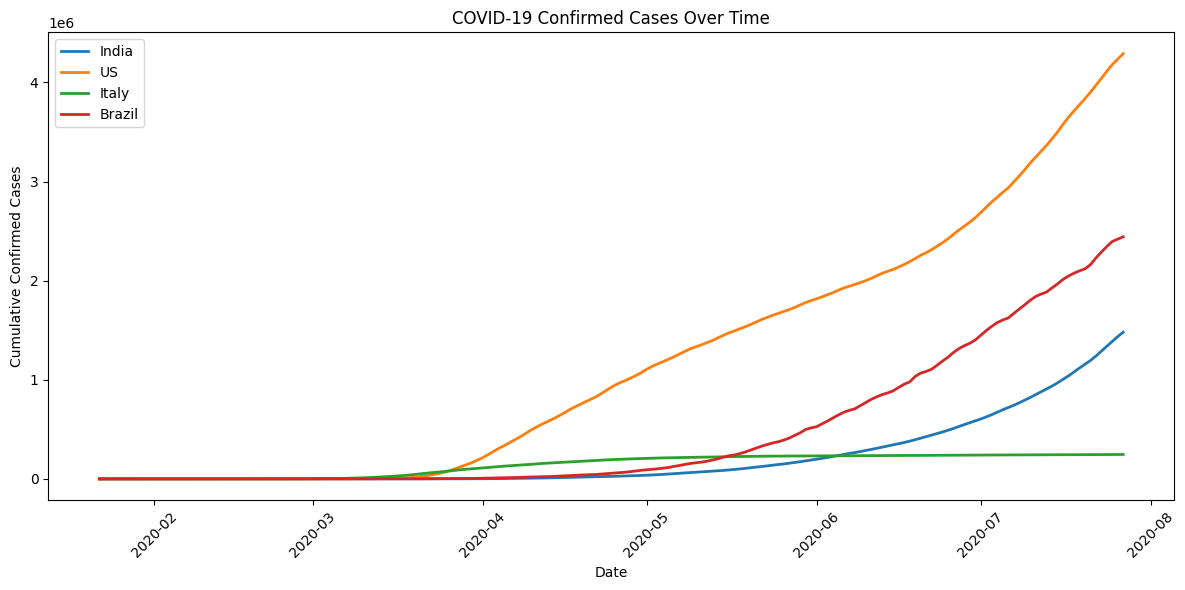

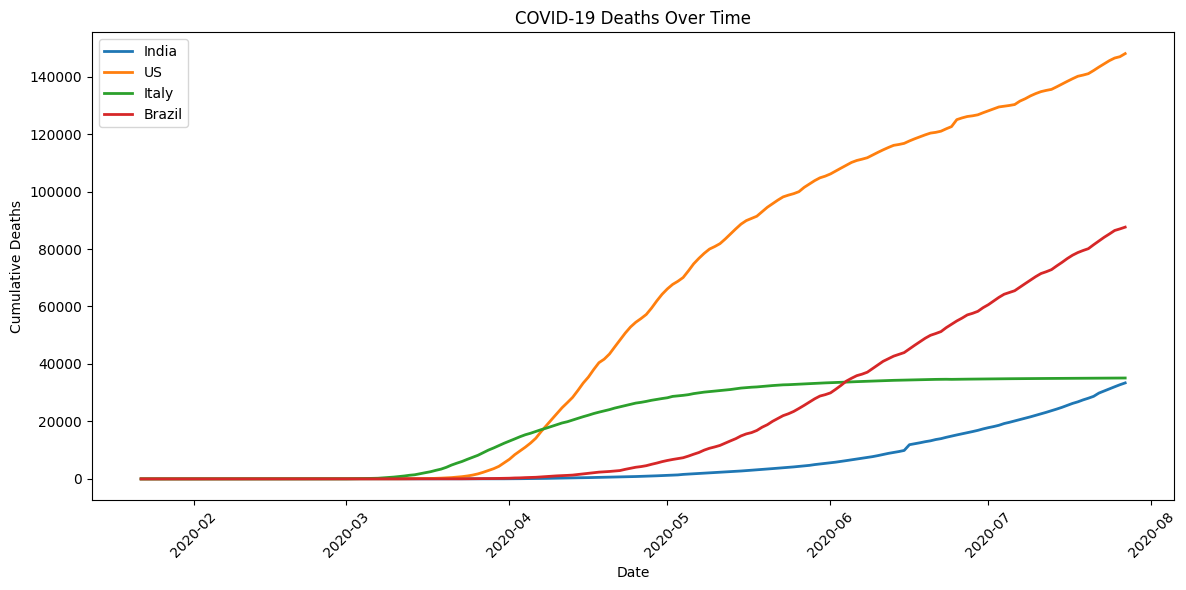

In [265]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
df = pd.read_csv("covid_19_clean_complete.csv", parse_dates=["Date"])

# -------------------------------------------------------
# PART 1: Country-level aggregation (latest snapshot)
# -------------------------------------------------------
# Get the most recent date in the dataset
latest_date = df["Date"].max()
print("Latest date:", latest_date)

# Filter to latest date and group by country
# (sum handles countries with multiple provinces e.g. USA, China)
latest = (df[df["Date"] == latest_date]
          .groupby("Country/Region")[["Confirmed", "Deaths", "Recovered", "Active"]]
          .sum()
          .sort_values("Confirmed", ascending=False))

print("\nTop 5 countries by confirmed cases:")
print(latest.head(5))

# -------------------------------------------------------
# PART 2: Confirmed cases over time — 4 countries
# -------------------------------------------------------
countries = ["India", "US", "Italy", "Brazil"]

plt.figure(figsize=(12, 6))

for country in countries:
    # Filter rows for this country
    country_df = df[df["Country/Region"] == country]
    # Sum across provinces/states for each date
    daily = country_df.groupby("Date")["Confirmed"].sum().reset_index()
    plt.plot(daily["Date"], daily["Confirmed"], label=country, linewidth=2)

plt.title("COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Confirmed Cases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# PART 3: Deaths over time — same countries
# -------------------------------------------------------
plt.figure(figsize=(12, 6))

for country in countries:
    country_df = df[df["Country/Region"] == country]
    daily = country_df.groupby("Date")["Deaths"].sum().reset_index()
    plt.plot(daily["Date"], daily["Deaths"], label=country, linewidth=2)

plt.title("COVID-19 Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Deaths")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# Pie Chart

In [ ]:
import pandas as pd
import plotly.express as px

# --- Load Netflix catalog ---
df = pd.read_csv("netflix_titles.csv")
# Columns: show_id, type (Movie/TV Show), title, director, release_year, rating, etc.

# --- Chart 1: Pie chart of content ratings ---
rating_counts = df.groupby("rating").size().reset_index(name="counts")

fig1 = px.pie(
    rating_counts,
    names="rating",
    title="Distribution of Content Ratings on Netflix",
    color_discrete_sequence=px.colors.qualitative.Set3
)
fig1.show()
# TV-MA is largest slice (mature content dominates)

# --- Chart 2: Line chart of content added over years ---
# Clean up: rename and filter recent years
yearly = (df
    .rename(columns={"release_year": "Release Year"})
    .groupby(["Release Year", "type"])
    .size()
    .reset_index(name="Total Content")
)
yearly = yearly[yearly["Release Year"] > 2010]

fig2 = px.line(
    yearly,
    x="Release Year",
    y="Total Content",
    color="type",        # separate line for Movies vs TV Shows
    title="Netflix Content Trend Over the Years",
    markers=True         # show dots at each year
)
fig2.show()
# Both Movies and TV Shows peak around 2019-2020, then drop (COVID + catalog strategy)

# --- Save as interactive HTML files ---
fig1.write_html("netflix_ratings_pie.html")
fig2.write_html("netflix_content_trend.html")

In [299]:
df = pd.read_csv("netflix_titles.csv")
rating_counts = df.groupby("rating").size().reset_index(name="counts")
rating_counts
fig1 = px.pie(rating_counts,names="rating",
    values="counts")
fig1.show()